# ============================================================
# PHASE 06 — APPLIED REPRESENTATION ANALYSIS
# STEP 04 — ATTENTION MAP VISUALIZATION
# ============================================================

# Repository Philosophy:
#
# Tensor intuition first.
# Representation systems second.
# Architecture complexity later.
#
# ------------------------------------------------------------
# CENTRAL QUESTION OF THIS STEP
# ------------------------------------------------------------
#
# How do transformers dynamically redistribute attention?
#
# Unlike static embeddings:
#
#     transformer representations are contextual.
#
# Tokens continuously influence each other through:
#
#     attention interactions.
#
# This step investigates:
#
#     • attention maps
#     • token interactions
#     • contextual information flow
#     • attention distributions
#     • dynamic representation routing
#
# using REAL transformer systems.
#
# ============================================================



============================================================
1. CONCEPTUAL INTRODUCTION
============================================================

CONCEPTUAL FOUNDATION
---------------------

Earlier steps investigated:

    static semantic geometry.

But transformers introduce something deeper:

    dynamic contextual interaction.

------------------------------------------------------------
THE LIMITATION OF STATIC EMBEDDINGS
------------------------------------------------------------

Static embeddings assign:

    one vector per word.

Example:

    bank

always receives:

    same representation.

But human language is contextual:

    river bank
    financial bank

possess different meanings.

------------------------------------------------------------
TRANSFORMER SOLUTION
------------------------------------------------------------

Transformers dynamically update representations
through:

    attention interactions.

Tokens "look at" other tokens
to gather contextual information.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Attention creates:

    dynamic interaction topology.

This means:

    information flow changes continuously
    depending on context.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could meaning itself emerge through:

    interaction patterns between representations?




============================================================
2. REPRESENTATION HYPOTHESIS
============================================================

REPRESENTATION HYPOTHESIS
-------------------------

Hypothesis:

    different tokens will attend
    to different contextual regions.

Expected observations:

    • verbs attend to subjects
    • pronouns attend to referenced nouns
    • important semantic words receive stronger attention

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Attention is NOT fixed.

It dynamically changes depending on:

    • sentence structure
    • semantic relationships
    • contextual dependencies

------------------------------------------------------------
TRANSFORMER INSIGHT
------------------------------------------------------------

Meaning may emerge through:

    contextual interaction dynamics.

------------------------------------------------------------
THINK DEEPLY
------------------------------------------------------------

Is attention:

    • information routing?
    • contextual retrieval?
    • dynamic memory access?
    • relational interaction?




============================================================
3. LOAD REAL TRANSFORMER SYSTEM
============================================================

We now load a REAL transformer model.

------------------------------------------------------------
MODEL
------------------------------------------------------------

We use:

    BERT (Bidirectional Encoder Representations
    from Transformers)

BERT revolutionized NLP through:

    contextual representation learning.

------------------------------------------------------------
WHY BERT?
------------------------------------------------------------

BERT provides:

    • attention weights
    • contextual embeddings
    • multi-head attention
    • layerwise representations

making it ideal for representation analysis.

------------------------------------------------------------
GLOSSARY OF FUNCTIONS
------------------------------------------------------------

BertTokenizer.from_pretrained(...)
    Loads pretrained tokenizer.

BertModel.from_pretrained(...)
    Loads pretrained transformer.

tokenizer(...)
    Converts text into token IDs.

output_attentions=True
    Returns attention matrices.

softmax(...)
    Converts scores into probabilities.

attention_weights
    Token-to-token interaction strengths.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Transformers do not process words independently.

Instead:

    representations continuously interact.




In [1]:

import torch

from transformers import (
    BertTokenizer,
    BertModel
)

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# Load transformer model
model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

print("Transformer system loaded successfully.")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer system loaded successfully.


============================================================
4. TOKENIZATION AND INPUT PROCESSING
============================================================

Transformers do NOT directly process raw text.

Instead:

    text -> tokens -> token IDs -> embeddings

------------------------------------------------------------
TOKENIZATION
------------------------------------------------------------

Example:

    "Transformers analyze context"

may become:

    ["transformers", "analyze", "context"]

or even:

    subword fragments.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Attention operates at:

    token level.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Which tokens will interact strongly?




In [2]:

sentence = (
    "The scientist analyzed the transformer attention map carefully."
)

# Tokenize sentence
inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

print("Input IDs shape:")
print(inputs["input_ids"].shape)




Input IDs shape:
torch.Size([1, 12])


In [3]:

# Convert token IDs back into readable tokens

tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

print("\nTOKENS\n")

print(tokens)
# Here now you feel what token is. 





TOKENS

['[CLS]', 'the', 'scientist', 'analyzed', 'the', 'transform', '##er', 'attention', 'map', 'carefully', '.', '[SEP]']


============================================================
5. ATTENTION MECHANISM MATHEMATICS
============================================================

CORE IDEA
---------

Attention computes:

    how strongly tokens interact.

------------------------------------------------------------
QUERY, KEY, VALUE
------------------------------------------------------------

Each token generates:

    • Query vector (Q)
    • Key vector (K)
    • Value vector (V)

------------------------------------------------------------
INTUITION
------------------------------------------------------------

Query:

    "What information am I looking for?"

Key:

    "What information do I contain?"

Value:

    "What information should I provide?"

============================================================
ATTENTION FORMULA
============================================================

Scaled dot-product attention:





where:

    Q = query matrix
    K = key matrix
    V = value matrix
    d_k = key dimension

------------------------------------------------------------
STEP-BY-STEP INTERPRETATION
------------------------------------------------------------

Step 1:

    Compute similarity:

        QKᵀ

This measures:

    token interaction strength.

------------------------------------------------------------
Step 2:

    Scale by:

        √d_k

to stabilize gradients.

------------------------------------------------------------
Step 3:

    Apply softmax

converting scores into:

    probability distribution.

------------------------------------------------------------
Step 4:

    Weighted combination of values.

This creates:

    context-aware representations.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Attention dynamically redistributes:

    information flow across tokens.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Is attention fundamentally:

    dynamic contextual routing?




============================================================
6. EXTRACT ATTENTION MAPS
============================================================

We now pass text through the transformer.

The model returns:

    • hidden states
    • attention weights

------------------------------------------------------------
ATTENTION TENSOR STRUCTURE
------------------------------------------------------------

Attention tensor dimensions:

    [batch, heads, tokens, tokens]

Example:

    [1, 12, 10, 10]

meaning:

    • 1 sentence
    • 12 attention heads
    • 10 query tokens
    • 10 key tokens

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Each attention head learns:

    different interaction patterns.




In [4]:

# Forward pass through transformer

with torch.no_grad():

    outputs = model(**inputs)

# Extract attention tensors
attentions = outputs.attentions

print("Number of transformer layers:")
print(len(attentions))

print("\nAttention tensor shape:")
print(attentions[0].shape)



Number of transformer layers:
12

Attention tensor shape:
torch.Size([1, 12, 12, 12])


============================================================
7. ATTENTION MAP VISUALIZATION
============================================================

Human beings cannot directly interpret:

    high-dimensional attention tensors.

So we visualize:

    attention heatmaps.

------------------------------------------------------------
HEATMAP INTERPRETATION
------------------------------------------------------------

Rows:

    query tokens

Columns:

    attended tokens

Bright regions:

    stronger attention interactions.

------------------------------------------------------------
IMPORTANT QUESTION
------------------------------------------------------------

Which tokens dominate information flow?




In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

# Select:
# Layer 0
# Head 0

attention_map = attentions[0][0][0].cpu().numpy()

print("Attention map shape:")
print(attention_map.shape)



Attention map shape:
(12, 12)


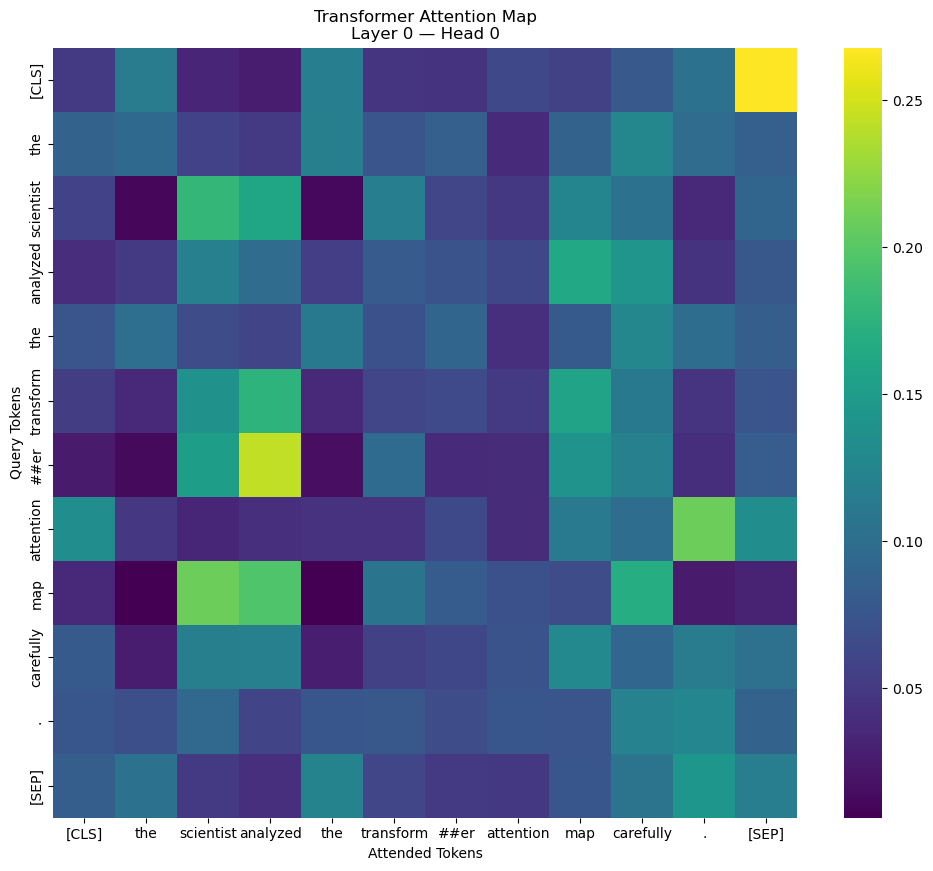

In [6]:

plt.figure(figsize=(12, 10))

sns.heatmap(
    attention_map,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis",
    annot=False
)

plt.title(
    "Transformer Attention Map\n"
    "Layer 0 — Head 0"
)

plt.xlabel("Attended Tokens")
plt.ylabel("Query Tokens")

plt.show()



============================================================
8. ATTENTION DISTRIBUTION ANALYSIS
============================================================

We now inspect:

    how strongly each token distributes attention.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Attention distributions reveal:

    contextual dependency structure.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Which tokens become:

    information hubs?




In [7]:

query_index = 3

query_token = tokens[query_index]

attention_distribution = attention_map[query_index]

print(f"\nATTENTION DISTRIBUTION FOR TOKEN: {query_token}\n")

for token, score in zip(tokens, attention_distribution):

    print(f"{token:15s} Attention: {score:.4f}")




ATTENTION DISTRIBUTION FOR TOKEN: analyzed

[CLS]           Attention: 0.0387
the             Attention: 0.0501
scientist       Attention: 0.1185
analyzed        Attention: 0.0976
the             Attention: 0.0535
transform       Attention: 0.0804
##er            Attention: 0.0732
attention       Attention: 0.0617
map             Attention: 0.1625
carefully       Attention: 0.1427
.               Attention: 0.0438
[SEP]           Attention: 0.0773


============================================================
9. INTERPRETATION
============================================================

OBSERVATION ANALYSIS
--------------------

Examine the attention map carefully.

Possible observations:

    • nearby words interact strongly
    • important nouns attract attention
    • verbs attend to subjects
    • punctuation influences structure

------------------------------------------------------------
IMPORTANT REALIZATION
------------------------------------------------------------

Transformers continuously:

    redistribute information flow.

This creates:

    dynamic contextual representations.

------------------------------------------------------------
ATTENTION AS TOPOLOGY
------------------------------------------------------------

Attention maps define:

    interaction topology between tokens.

This topology changes:

    sentence-by-sentence.

------------------------------------------------------------
VERY IMPORTANT INSIGHT
------------------------------------------------------------

Meaning may emerge through:

    contextual interaction patterns

rather than isolated representations.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could cognition itself emerge through:

    dynamic routing of information?




============================================================
10. FAILURE CASES
============================================================

REAL SYSTEMS ARE IMPERFECT
--------------------------

Attention analysis possesses limitations.

------------------------------------------------------------
LIMITATION 1 — ATTENTION IS NOT EXPLANATION
------------------------------------------------------------

High attention does NOT necessarily imply:

    causal importance.

Attention reflects:

    interaction weighting

not guaranteed reasoning.

------------------------------------------------------------
LIMITATION 2 — MULTI-HEAD COMPLEXITY
------------------------------------------------------------

Different heads learn:

    different relational structures.

One heatmap captures only:

    partial system behavior.

------------------------------------------------------------
LIMITATION 3 — CONTEXT DEPENDENCE
------------------------------------------------------------

Attention changes dynamically
across different sentences.

------------------------------------------------------------
LIMITATION 4 — VISUALIZATION DISTORTION
------------------------------------------------------------

Heatmaps simplify:

    extremely high-dimensional interactions.

------------------------------------------------------------
THINK CRITICALLY
------------------------------------------------------------

Is attention sufficient to explain:

    transformer reasoning?




============================================================
11. SCIENTIFIC INSIGHT
============================================================

MOST IMPORTANT INSIGHT
----------------------

Transformers operate through:

    dynamic representation interaction.

------------------------------------------------------------
ATTENTION ENABLES
------------------------------------------------------------

    • contextual reasoning
    • semantic disambiguation
    • long-range dependency modeling
    • information routing
    • adaptive contextualization

------------------------------------------------------------
FOUNDATIONAL REALIZATION
------------------------------------------------------------

Meaning is NOT static.

It continuously evolves through:

    contextual interaction dynamics.

------------------------------------------------------------
IMPORTANT TRANSITION
------------------------------------------------------------

We are no longer studying:

    isolated embedding geometry

but:

    dynamic information flow systems.

------------------------------------------------------------
LOOK AHEAD
------------------------------------------------------------

Next steps investigate:

    • token interaction analysis
    • head specialization
    • contextual representation shift
    • layerwise representation evolution

We are progressively uncovering:

    AI as adaptive representation routing.




============================================================
12. EXPLORATION EXERCISES
============================================================

EXPLORATION 1
-------------

Try ambiguous sentences:

    "The bank approved the loan."
    "The boat reached the bank."

How does attention change?

------------------------------------------------------------
EXPLORATION 2
-------------

Compare short and long sentences.

Does attention become:

    more distributed?

------------------------------------------------------------
EXPLORATION 3
-------------

Visualize:

    different transformer layers.

Do deeper layers learn:

    different interaction structures?

------------------------------------------------------------
EXPLORATION 4
-------------

Compare:

    different attention heads.

Do some heads specialize in:

    syntax?
    semantics?
    positional structure?

------------------------------------------------------------
EXPLORATION 5
-------------

Replace BERT with:

    • DistilBERT
    • RoBERTa
    • GPT-2

How does attention topology change?

------------------------------------------------------------
FINAL QUESTION
------------------------------------------------------------

If modern AI systems fundamentally operate through:

    dynamic information routing,

then could intelligence itself emerge from:

    adaptive interaction topology?

============================================================


# ------------------------------------------------------------
# NOTE ON SPECIAL TOKENS: [CLS] AND [SEP]
# ------------------------------------------------------------
#
# While inspecting transformer tokens,
# learners may notice:
#
#     [CLS]
#     [SEP]
#
# appearing in tokenized outputs.
#
# Example:
#
#     ['[CLS]',
#      'the',
#      'scientist',
#      'analyzed',
#      'the',
#      'transformer',
#      '.',
#      '[SEP]']
#
# These are NOT ordinary language words.
#
# They are:
#
#     special structural tokens
#
# introduced by the transformer architecture.
#
# ============================================================
# [CLS] TOKEN
# ============================================================
#
# Meaning:
#
#     CLS = Classification Token
#
# It is inserted at:
#
#     the beginning of every sequence.
#
# ------------------------------------------------------------
# PURPOSE
# ------------------------------------------------------------
#
# The [CLS] token acts like:
#
#     a global semantic collector.
#
# During attention computation:
#
#     [CLS] interacts with all tokens.
#
# Over multiple transformer layers:
#
#     [CLS] gradually accumulates
#     contextual information
#
# about the entire sentence.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# The final representation of [CLS]
# is often used as:
#
#     sentence-level representation.
#
# This becomes useful for:
#
#     • classification
#     • sentiment analysis
#     • semantic understanding
#     • retrieval systems
#
# ------------------------------------------------------------
# DEEP INTERPRETATION
# ------------------------------------------------------------
#
# You can think of [CLS] as:
#
#     a dynamically evolving
#     global semantic state.
#
# ============================================================
# [SEP] TOKEN
# ============================================================
#
# Meaning:
#
#     SEP = Separator Token
#
# It is used to:
#
#     separate semantic regions.
#
# ------------------------------------------------------------
# PURPOSE
# ------------------------------------------------------------
#
# Example:
#
#     Sentence A [SEP] Sentence B [SEP]
#
# This helps transformers identify:
#
#     sequence boundaries.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# Transformers do NOT inherently understand:
#
#     • sentence starts
#     • sentence endings
#     • sequence boundaries
#
# Special tokens provide:
#
#     structural anchors
#
# inside representation space.
#
# ============================================================
# IMPORTANT QUESTION
# ============================================================
#
# Are these tokens passive markers?
#
# No.
#
# [CLS] and [SEP] participate in:
#
#     attention interactions
#
# just like ordinary tokens.
#
# They possess:
#
#     • embeddings
#     • attention weights
#     • contextual representations
#
# and evolve dynamically through transformer layers.
#
# ============================================================
# VERY IMPORTANT SYSTEMS INSIGHT
# ============================================================
#
# Transformers are NOT simply processing words.
#
# They are constructing:
#
#     structured interaction systems
#
# composed of:
#
#     • semantic tokens
#     • structural tokens
#     • positional encodings
#     • contextual routing patterns
#
# all interacting inside:
#
#     dynamic representation geometry.
#


# ============================================================
# THEORETICAL DEFINITION OF TRANSFORMERS
# ============================================================
#
# A transformer is a neural architecture designed to model:
#
#     contextual relationships between tokens
#
# through:
#
#     attention-based interaction mechanisms.
#
# ------------------------------------------------------------
# CORE IDEA
# ------------------------------------------------------------
#
# Instead of processing sequences:
#
#     step-by-step
#
# like recurrent systems,
#
# transformers process:
#
#     all tokens simultaneously
#
# while dynamically computing:
#
#     token-to-token interaction strengths.
#
# ------------------------------------------------------------
# FORMAL DEFINITION
# ------------------------------------------------------------
#
# A transformer is a parameterized function:
#
#     F(X) → Y
#
# where:
#
#     X = input token representations
#     Y = contextualized output representations
#
# The transformation occurs through:
#
#     repeated attention and feedforward operations.
#
# ============================================================
# TRANSFORMER PIPELINE
# ============================================================
#
# INPUT TEXT
#
#     ↓
#
# TOKENIZATION
#
#     ↓
#
# TOKEN EMBEDDINGS
#
#     ↓
#
# POSITIONAL ENCODINGS
#
#     ↓
#
# MULTI-HEAD SELF-ATTENTION
#
#     ↓
#
# FEEDFORWARD TRANSFORMATION
#
#     ↓
#
# CONTEXTUAL REPRESENTATIONS
#
# ============================================================
# KEY ARCHITECTURAL COMPONENTS
# ============================================================
#
# 1. TOKEN EMBEDDINGS
# ------------------------------------------------------------
#
# Words become:
#
#     dense numerical vectors.
#
# Example:
#
#     "cat" → vector
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# Tokens are transformed into:
#
#     geometric states
#
# inside representation space.
#
# ============================================================
# 2. POSITIONAL ENCODINGS
# ============================================================
#
# Transformers process tokens in parallel.
#
# Therefore:
#
#     sequence order must be injected explicitly.
#
# Positional encoding provides:
#
#     order information.
#
# ------------------------------------------------------------
# POSITIONAL FORMULATION
# ------------------------------------------------------------
#


#
# where:
#
#     pos = token position
#     i   = embedding dimension index
#     d   = embedding dimension
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Position itself becomes:
#
#     representable geometry.
#
# ============================================================
# 3. SELF-ATTENTION
# ============================================================
#
# Self-attention computes:
#
#     contextual token interactions.
#
# Each token produces:
#
#     • Query vector (Q)
#     • Key vector (K)
#     • Value vector (V)
#
# ------------------------------------------------------------
# ATTENTION EQUATION
# ------------------------------------------------------------
#



#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# The transformer dynamically determines:
#
#     which tokens influence each other.
#
# ------------------------------------------------------------
# IMPORTANT IDEA
# ------------------------------------------------------------
#
# Meaning emerges through:
#
#     contextual interaction.
#
# ============================================================
# 4. MULTI-HEAD ATTENTION
# ============================================================
#
# Transformers use:
#
#     multiple attention heads simultaneously.
#
# Each head may learn:
#
#     different relational structures.
#
# Example:
#
#     • syntax
#     • semantics
#     • long-range dependencies
#     • positional relationships
#
# ------------------------------------------------------------
# MULTI-HEAD FORMULATION
# ------------------------------------------------------------
#


#
# where:
#
#     head_i = independent attention head
#     W^O    = output projection matrix
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Transformers process:
#
#     multiple relational perspectives
#
# simultaneously.
#
# ============================================================
# 5. FEEDFORWARD NETWORK
# ============================================================
#
# After attention interaction,
#
# each token representation passes through:
#
#     nonlinear feedforward transformations.
#
# ------------------------------------------------------------
# FORMULATION
# ------------------------------------------------------------
#



#
# ------------------------------------------------------------
# PURPOSE
# ------------------------------------------------------------
#
# This allows:
#
#     nonlinear representation transformation.
#
# ============================================================
# 6. LAYER STACKING
# ============================================================
#
# Transformers stack:
#
#     multiple attention layers.
#
# This creates:
#
#     hierarchical representation evolution.
#
# Earlier layers:
#
#     local structure
#
# Later layers:
#
#     abstract semantics
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Representations continuously evolve
# across transformer depth.
#
# ============================================================
# MOST IMPORTANT THEORETICAL INSIGHT
# ============================================================
#
# Transformers fundamentally operate as:
#
#     dynamic representation routing systems.
#
# They do NOT primarily memorize symbols.
#
# Instead they:
#
#     • contextualize representations
#     • redistribute information flow
#     • construct interaction topology
#     • evolve latent semantic states
#
# through:
#
#     repeated attention-based transformations.
#
# ============================================================
# DEEP QUESTION
# ============================================================
#
# If intelligence emerges through:
#
#     dynamic contextual interaction,
#
# then are transformers approximating:
#
#     computational cognition systems?
#


# ============================================================
# FORMAL DEFINITION OF THE ATTENTION MATRIX
# ============================================================
#
# The attention matrix represents:
#
#     token-to-token interaction strengths
#
# inside transformer systems.
#
# ------------------------------------------------------------
# CORE IDEA
# ------------------------------------------------------------
#
# Each token computes:
#
#     how strongly it should attend
#     to every other token.
#
# This produces:
#
#     a dynamic interaction matrix.
#
# ============================================================
# QUERY-KEY INTERACTION
# ============================================================
#
# Suppose:
#
#     Q ∈ R^(n × d_k)
#     K ∈ R^(n × d_k)
#
# where:
#
#     n   = number of tokens
#     d_k = key/query dimension
#
# ------------------------------------------------------------
# QUERY MATRIX
# ------------------------------------------------------------
#
# Each row:
#
#     Q_i
#
# asks:
#
#     "What information am I searching for?"
#
# ------------------------------------------------------------
# KEY MATRIX
# ------------------------------------------------------------
#
# Each row:
#
#     K_j
#
# represents:
#
#     "What information do I contain?"
#
# ============================================================
# RAW ATTENTION SCORES
# ============================================================
#
# Attention scores are computed using:
#



#
# where:
#
#     S ∈ R^(n × n)
#
# ------------------------------------------------------------
# MATRIX INTERPRETATION
# ------------------------------------------------------------
#
# Each matrix entry:
#
#     S(i,j)
#
# measures:
#
#     interaction strength between
#     token i and token j.
#
# ------------------------------------------------------------
# GEOMETRIC INTERPRETATION
# ------------------------------------------------------------
#
# Dot product similarity:
#
#     Q_i · K_j
#
# measures:
#
#     directional alignment
#
# between query and key vectors.
#
# Larger dot product:
#
#     stronger contextual relevance.
#
# ============================================================
# SCALED ATTENTION SCORES
# ============================================================
#
# Raw scores are scaled:
#

:contentReference[oaicite:1]{index=1}

#
# where:
#
#     d_k = key dimension
#
# ------------------------------------------------------------
# WHY SCALE?
# ------------------------------------------------------------
#
# In high dimensions:
#
#     dot products grow large.
#
# Large values may destabilize:
#
#     softmax gradients.
#
# Scaling stabilizes:
#
#     optimization dynamics.
#
# ============================================================
# ATTENTION MATRIX
# ============================================================
#
# The final attention matrix is:
#

:contentReference[oaicite:2]{index=2}

#
# where:
#
#     A ∈ R^(n × n)
#
# ------------------------------------------------------------
# IMPORTANT PROPERTY
# ------------------------------------------------------------
#
# Each row of A becomes:
#
#     a probability distribution.
#
# Therefore:
#
#     Σ_j A(i,j) = 1
#
# for every token i.
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Row i:
#
#     how token i distributes attention
#     across all tokens.
#
# Column j:
#
#     how strongly other tokens attend
#     to token j.
#
# ============================================================
# FINAL REPRESENTATION UPDATE
# ============================================================
#
# Attention weights are used to compute:
#
#     contextualized representations.
#
# Final output:
#



#
# where:
#
#     V = value matrix
#     Z = contextualized token representations
#
# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------
#
# Each token representation becomes:
#
#     weighted combination of other tokens.
#
# This creates:
#
#     context-aware semantic states.
#
# ============================================================
# DIMENSIONAL STRUCTURE
# ============================================================
#
# Suppose:
#
#     n = 10 tokens
#
# Then:
#
#     Attention Matrix Shape:
#
#         A ∈ R^(10 × 10)
#
# meaning:
#
#     every token interacts
#     with every other token.
#
# ------------------------------------------------------------
# IMPORTANT INSIGHT
# ------------------------------------------------------------
#
# Attention creates:
#
#     fully connected interaction topology.
#
# ============================================================
# ALGORITHMIC FORM
# ============================================================
#
# INPUT:
#
#     Token representations X
#
# ------------------------------------------------------------
# STEP 1
# ------------------------------------------------------------
#
# Compute query matrix:
#
#     Q = XW_Q
#
# ------------------------------------------------------------
# STEP 2
# ------------------------------------------------------------
#
# Compute key matrix:
#
#     K = XW_K
#
# ------------------------------------------------------------
# STEP 3
# ------------------------------------------------------------
#
# Compute value matrix:
#
#     V = XW_V
#
# ------------------------------------------------------------
# STEP 4
# ------------------------------------------------------------
#
# Compute similarity scores:
#



#
# ------------------------------------------------------------
# STEP 5
# ------------------------------------------------------------
#
# Scale scores:
#



#
# ------------------------------------------------------------
# STEP 6
# ------------------------------------------------------------
#
# Apply softmax:
A mathematical function that converts a vector of raw, unnormalized scores (often called logits) into a valid probability distribution. It transforms the numbers so that they are all strictly positive and sum exactly to 1.0, making them interpretable as probabilities.
#



#
# ------------------------------------------------------------
# STEP 7
# ------------------------------------------------------------
#
# Compute contextualized outputs:
#



#
# OUTPUT:
#
#     Context-aware token representations
#
# ============================================================
# DEEP SYSTEMS INSIGHT
# ============================================================
#
# The attention matrix is NOT merely:
#
#     a lookup table.
#
# It is:
#
#     a dynamically evolving interaction graph
#
# between representations.
#
# Transformers fundamentally operate through:
#
#     adaptive information routing.
#
# ============================================================
# DEEP QUESTION
# ============================================================
#
# If attention matrices define:
#
#     interaction topology,
#
# then could cognition itself emerge from:
#
#     dynamically evolving interaction graphs?
#